In [1]:
#Cargo las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leer el archivo Parquet como DataFrame
df = pd.read_parquet('C:/Users/jugas/OneDrive/Escritorio/Movie recommender/MVP_sistema_recomendacion/proyecto/data/movies.parquet')

# Mostrar las primeras filas del DataFrame
df.head(15)

,id,titulo,sinopsis,tokens_sinopsis,fecha_estreno,puntuacion,numero_votos,generos,idioma_original,idiomas_disponibles,reseñas
0,120,El señor de los anillos: La comunidad del anillo,"En la Tierra Media, el Señor Oscuro Saurón cre...","[En, la, Tierra, Media, ,, el, Señor, Oscuro, ...",2001-12-18,8.418,25770,"[Aventura, Fantasía, Acción]",en,[English],[]
1,27205,Origen,"Dom Cobb es un ladrón hábil, el mejor de todos...","[Dom, Cobb, es, un, ladrón, hábil, ,, el, mejo...",2010-07-15,8.369,37220,"[Acción, Ciencia ficción, Aventura]",en,"[English, Français, 日本語, Kiswahili]",[Estamos ante una excelente y ambiciosa trama ...
2,1244361,Operación Zombie: Resurrección,Los soldados tailandeses inexpertos luchan con...,"[Los, soldados, tailandeses, inexpertos, lucha...",2024-07-20,3.900,11,"[Terror, Acción, Suspense]",th,"[日本語, ภาษาไทย]",[]
3,9615,A todo gas: Tokyo Race,Shaun Boswell es un chico que no acaba de enca...,"[Shaun, Boswell, es, un, chico, que, no, acaba...",2006-06-03,6.500,7046,"[Acción, Crimen, Drama, Suspense]",en,"[English, 日本語]",[]
4,667538,Transformers: El despertar de las bestias,Cuando surge una nueva amenaza capaz de destru...,"[Cuando, surge, una, nueva, amenaza, capaz, de...",2023-06-06,7.246,4842,"[Ciencia ficción, Aventura, Acción]",en,"[, Español, English]",[Transformers El Despertar de las Bestias (**T...
5,839033,El señor de los anillos: La guerra de los Rohi...,"Explora la ""historia no contada"" del Abismo de...","[Explora, la, "", historia, no, contada, "", del...",2024-12-05,6.600,503,"[Animación, Fantasía, Aventura, Acción]",en,[English],[]
6,1356039,Contraataque,"En una misión de rescate de rehenes, el capitá...","[En, una, misión, de, rescate, de, rehenes, ,,...",2025-02-27,8.496,524,"[Acción, Aventura, Suspense]",es,[Español],[]
7,426063,Nosferatu,Historia gótica de obsesión entre una joven he...,"[Historia, gótica, de, obsesión, entre, una, j...",2024-12-25,6.708,2401,"[Fantasía, Terror]",en,"[Deutsch, English, Español, Română, Pусский]","[""**Nosferatu**,"" dirigida por Robert Eggers, ..."
8,993710,De vuelta a la acción,Emily y Matt renunciaron hace años a ser espía...,"[Emily, y, Matt, renunciaron, hace, años, a, s...",2025-01-15,6.449,1113,"[Acción, Comedia]",en,"[English, Polski]",[(ESPAÑOL) De vuelta a la acción busca reunir ...
9,950396,El abismo secreto,Dos agentes de élite son secretamente asignado...,"[Dos, agentes, de, élite, son, secretamente, a...",2025-02-13,7.747,2123,"[Romance, Ciencia ficción, Suspense]",en,"[English, Lietuvių]",[]


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   300 non-null    int64  
 1   titulo               300 non-null    object 
 2   sinopsis             300 non-null    object 
 3   tokens_sinopsis      300 non-null    object 
 4   fecha_estreno        299 non-null    object 
 5   puntuacion           300 non-null    float64
 6   numero_votos         300 non-null    int64  
 7   generos              300 non-null    object 
 8   idioma_original      300 non-null    object 
 9   idiomas_disponibles  300 non-null    object 
 10  reseñas              300 non-null    object 
dtypes: float64(1), int64(2), object(8)
memory usage: 25.9+ KB


In [4]:
print(df.isnull().sum())

id                     0
titulo                 0
sinopsis               0
tokens_sinopsis        0
fecha_estreno          1
puntuacion             0
numero_votos           0
generos                0
idioma_original        0
idiomas_disponibles    0
reseñas                0
dtype: int64


## Gráfico de Distribución de Géneros en las Películas

Este gráfico de barras horizontales muestra la distribución de géneros en las películas del conjunto de datos. 


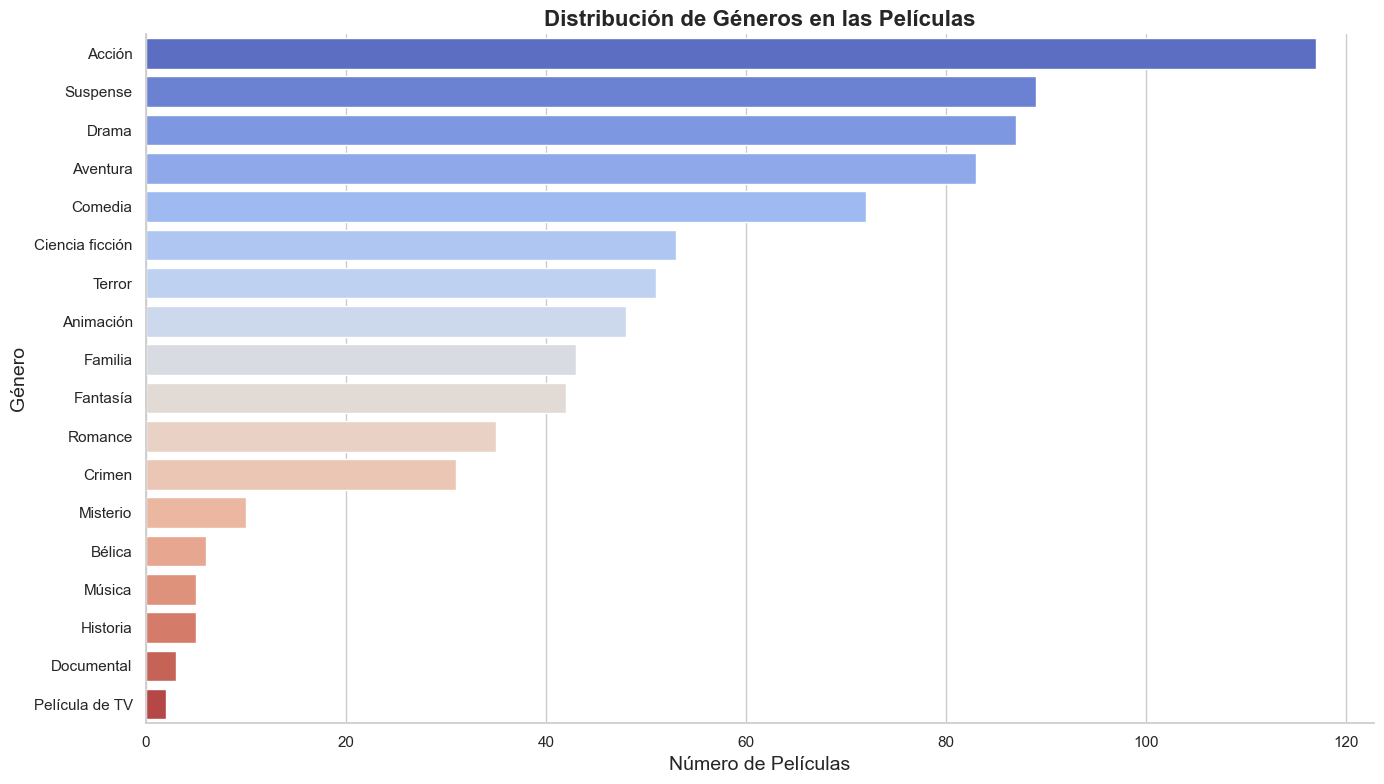

In [5]:
# Configuración de estilo de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Contamos los géneros de manera que eliminamos duplicados y luego los ordenamos
genre_counts = df['generos'].explode().value_counts()

# Crear gráfico de barras horizontales
plt.figure(figsize=(14, 8))
ax = sns.barplot(y=genre_counts.index, x=genre_counts.values, hue=genre_counts.index, palette="coolwarm", legend=False)

# Mejoramos la apariencia
plt.xlabel('Número de Películas', fontsize=14)
plt.ylabel('Género', fontsize=14)
plt.title('Distribución de Géneros en las Películas', fontsize=16, weight='bold')

# Mejorando el diseño general
sns.despine()  # Remueve los bordes para una apariencia más limpia
plt.tight_layout()  # Ajusta los elementos para que no se sobrepongan

plt.show()



## Gráfico de Puntuación Promedio por Género

Este gráfico de barras muestra la puntuación promedio de las películas, agrupadas por género, de mayor a menor.


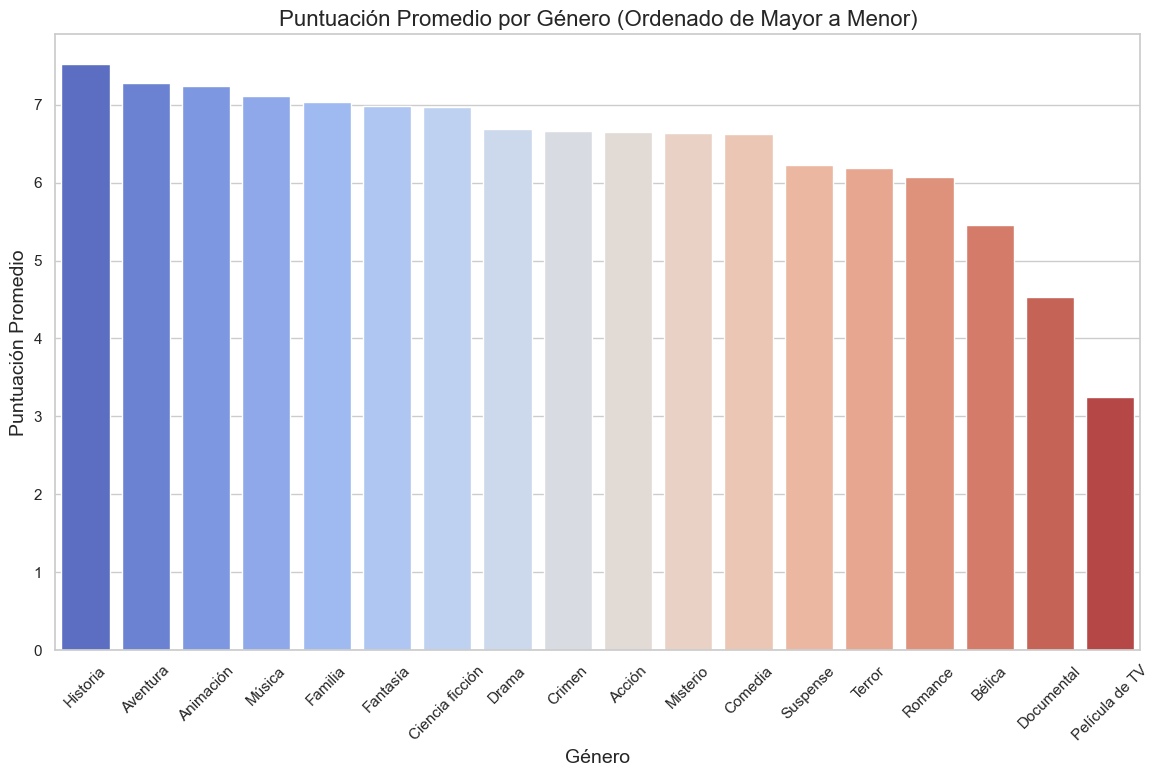

In [6]:
# Configuración de estilo de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Preparamos los datos para la visualización
df_exploded = df.explode('generos')  # Expandimos los géneros para que cada fila tenga un solo género

# Aseguramos que no haya duplicados en los géneros para cada película
df_exploded = df_exploded.drop_duplicates(subset=['id', 'generos'])

# Eliminar índices duplicados
df_exploded = df_exploded.reset_index(drop=True)

# Calcular la puntuación promedio por género
average_score_by_genre = df_exploded.groupby('generos')['puntuacion'].mean().sort_values(ascending=False)

# Crear gráfico de barras para mostrar los géneros ordenados por la puntuación promedio
plt.figure(figsize=(14, 8))
sns.barplot(x=average_score_by_genre.index, y=average_score_by_genre.values, hue=average_score_by_genre.index, palette="coolwarm", legend=False)

# Mejoramos la apariencia
plt.xlabel('Género', fontsize=14)
plt.ylabel('Puntuación Promedio', fontsize=14)
plt.title('Puntuación Promedio por Género (Ordenado de Mayor a Menor)', fontsize=16)
plt.xticks(rotation=45)
plt.show()


## Conteo de Idiomas Originales en las Películas

Este gráfico de barras muestra la distribución de los idiomas originales en las películas del conjunto de datos. 


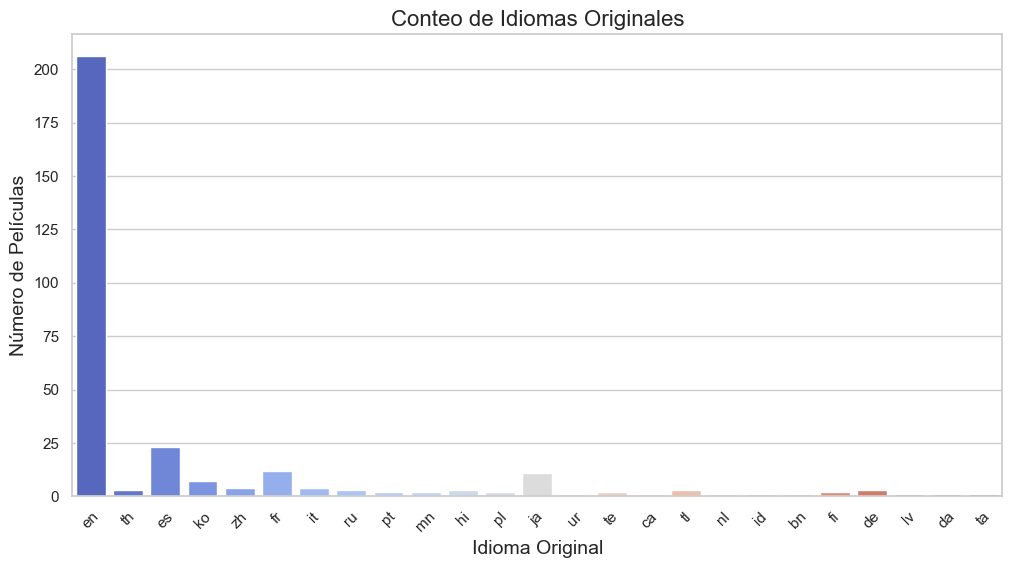

In [7]:
# Configuración de estilo de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Crear gráfico de barras para el conteo de idiomas originales
plt.figure(figsize=(12, 6))
sns.countplot(x='idioma_original', data=df, hue='idioma_original', palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.xlabel('Idioma Original', fontsize=14)
plt.ylabel('Número de Películas', fontsize=14)
plt.title('Conteo de Idiomas Originales', fontsize=16)
plt.show()



## Conteo de los 10 Idiomas Originales Más Frecuentes en las Películas (Derivado del Gráfico Anterior)

Este gráfico es una versión derivada del gráfico de **Conteo de Idiomas Originales**, donde se limita a mostrar solo los 10 idiomas más frecuentes. 



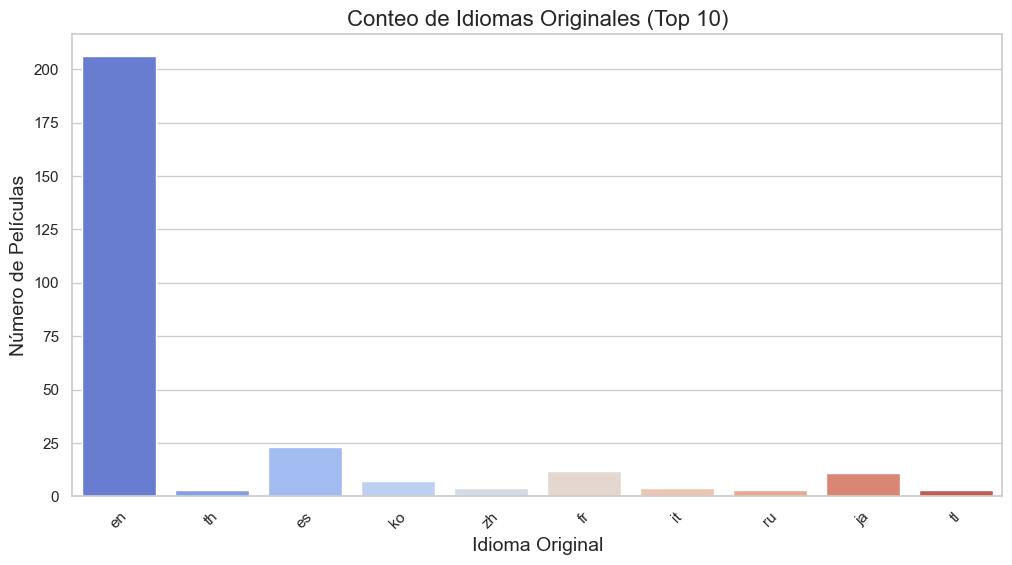

In [8]:
# Configuración de estilo de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Conteo de la frecuencia de cada idioma original
conteo_idiomas = df['idioma_original'].value_counts()

# Seleccionar los 10 idiomas más frecuentes
idiomas_frecuentes = conteo_idiomas.head(10).index

# Filtrar el DataFrame original para dejar solo las películas de los idiomas más frecuentes
df_filtrado = df[df['idioma_original'].isin(idiomas_frecuentes)]

# Crear gráfico de barras para el conteo de idiomas originales
plt.figure(figsize=(12, 6))
sns.countplot(x='idioma_original', data=df_filtrado, hue='idioma_original', palette="coolwarm", legend=False)
plt.xticks(rotation=45)
plt.xlabel('Idioma Original', fontsize=14)
plt.ylabel('Número de Películas', fontsize=14)
plt.title('Conteo de Idiomas Originales (Top 10)', fontsize=16)
plt.show()


### Gráfico de Distribución de Estrenos por Año

Este gráfico de líneas muestra la distribución de los estrenos de películas a lo largo de los años. Utilizando la columna `fecha_estreno`, se extrae el año de estreno y se agrupan las películas por año para contar el número de estrenos en cada uno. El gráfico permite observar las tendencias de los estrenos, como los picos o caídas de la cantidad de películas estrenadas en años específicos.


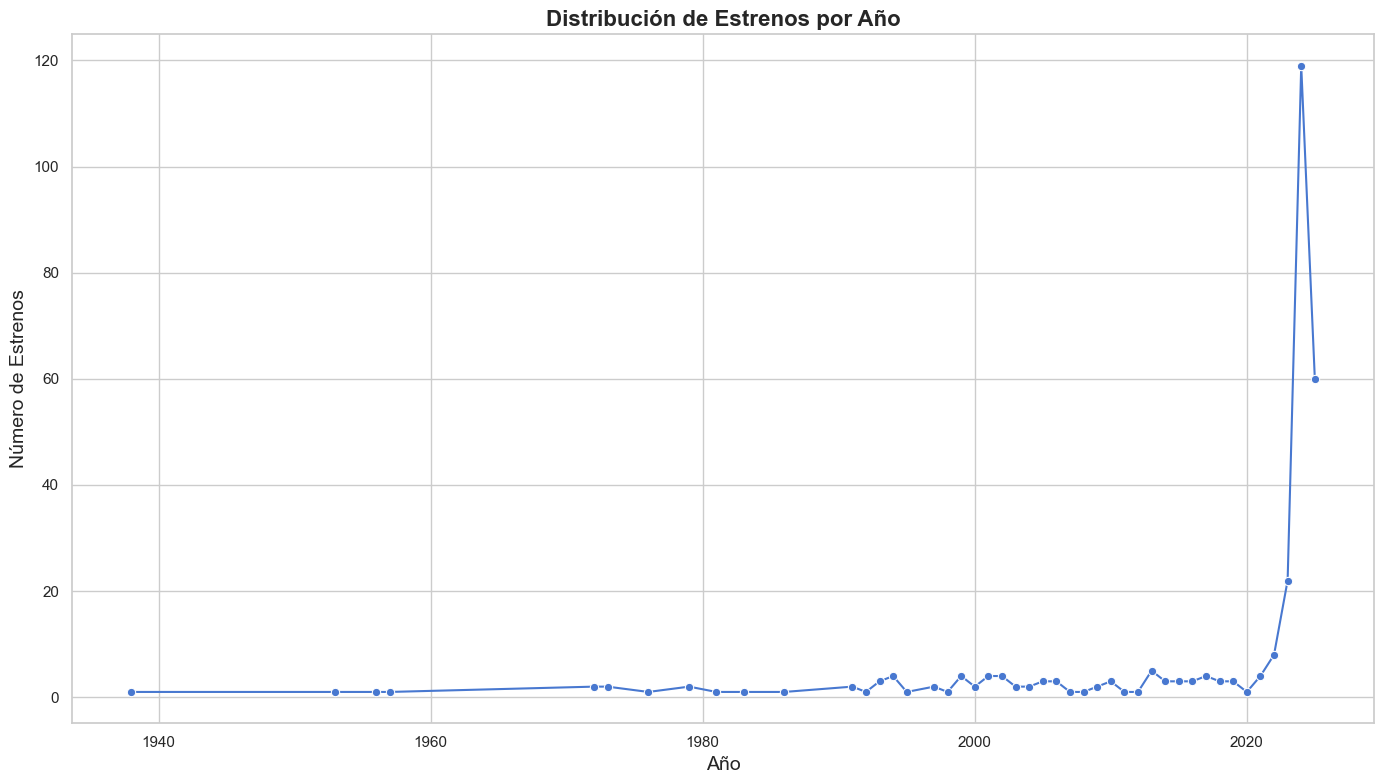

In [9]:
# Convertir la columna 'fecha_estreno' a datetime
df['fecha_estreno'] = pd.to_datetime(df['fecha_estreno'], errors='coerce')

# Ahora podemos extraer el año de 'fecha_estreno'
df['anio_estreno'] = df['fecha_estreno'].dt.year

# Configuración de estilo de seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Extraemos el año de la columna 'fecha_estreno' y lo agregamos como nueva columna 'release_year'
df['anio_estreno'] = df['fecha_estreno'].dt.year

# Agrupar los datos por año de estreno y contar el número de estrenos por año
df_agrupado = df.groupby('anio_estreno')['titulo'].count().reset_index(name='num_estrenos')

# Crear gráfico de línea para la distribución de estrenos anuales
plt.figure(figsize=(14, 8))
sns.lineplot(x='anio_estreno', y='num_estrenos', data=df_agrupado, marker='o', color='b')

# Mejoramos la apariencia
plt.title('Distribución de Estrenos por Año', fontsize=16, weight='bold')
plt.xlabel('Año', fontsize=14)
plt.ylabel('Número de Estrenos', fontsize=14)

# Ajustamos el diseño para evitar solapamientos
plt.tight_layout()

plt.show()



### Filtrado de Estrenos Previos a 1980  
Se eliminan del dataset las películas estrenadas antes de 1980 para centrarse en producciones más recientes.  


In [10]:
df = df[df['anio_estreno'] >= 1980]


### Creación de Variables Dummy para los 18 Géneros Más Puntuados

1. **Contamos y seleccionamos los 18 géneros más puntuados** utilizando la puntuación promedio.
2. **Convertimos los géneros en columnas dummy** con `str.get_dummies()` para cada película.

In [11]:
# Contar la frecuencia de los géneros
df_exploded = df.explode('generos')  # Expandimos los géneros para que cada fila tenga un solo género
df_exploded = df_exploded.drop_duplicates(subset=['id', 'generos'])  # Eliminamos duplicados de géneros

# Ordenamos los géneros por la puntuación promedio
average_score_by_genre = df_exploded.groupby('generos')['puntuacion'].mean().sort_values(ascending=False)

# Seleccionamos los 18 géneros más puntuados
top_18_genres = average_score_by_genre.head(18).index

# Filtrar el DataFrame para incluir solo los géneros más puntuados
df_filtered = df_exploded[df_exploded['generos'].isin(top_18_genres)]

# Convertir los géneros en columnas dummy
df_genres_dummies = df_filtered['generos'].str.get_dummies()
print(df_genres_dummies)


     Acción  Animación  Aventura  Bélica  Ciencia ficción  Comedia  Crimen  \
0         0          0         1       0                0        0       0   
0         0          0         0       0                0        0       0   
0         1          0         0       0                0        0       0   
1         1          0         0       0                0        0       0   
1         0          0         0       0                1        0       0   
..      ...        ...       ...     ...              ...      ...     ...   
298       0          0         0       0                0        0       0   
299       0          0         0       0                0        0       0   
299       0          0         0       0                0        1       0   
299       0          0         1       0                0        0       0   
299       0          1         0       0                0        0       0   

     Documental  Drama  Familia  Fantasía  Historia  Misterio  

### Cálculo de Popularidad de Películas  

Para medir la popularidad, combinamos la puntuación (`puntuacion`) y el número de votos (`numero_votos`) usando la **Media Ponderada de IMDb**. Aplicamos la fórmula:  

\[
WR = \frac{v}{v + m} R + \frac{m}{v + m} C
\]

donde ponderamos la puntuación según la cantidad de votos y un umbral mínimo (`m`), evitando que películas con pocos votos dominen el ranking.  


In [12]:
# Definir el umbral mínimo de votos (m) como el percentil 90
m = df['numero_votos'].quantile(0.90)

# Calcular la puntuación promedio de todas las películas (C)
C = df['puntuacion'].mean()

# Aplicar la fórmula de popularidad directamente en el DataFrame original
df['popularidad'] = ((df['numero_votos'] / (df['numero_votos'] + m) * df['puntuacion']) +
                     (m / (df['numero_votos'] + m) * C))

# Reemplazar NaN con 0 en las películas con menos votos
df['popularidad'].fillna(0, inplace=True)

C:\Users\jugas\AppData\Local\Temp\ipykernel_6912\3210512327.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['popularidad'].fillna(0, inplace=True)


## Correlación entre Géneros y Popularidad  

Se analiza la relación entre los géneros de las películas y su popularidad mediante una matriz de correlación. Esto permite visualizar qué géneros tienen mayor impacto en la popularidad de las películas.


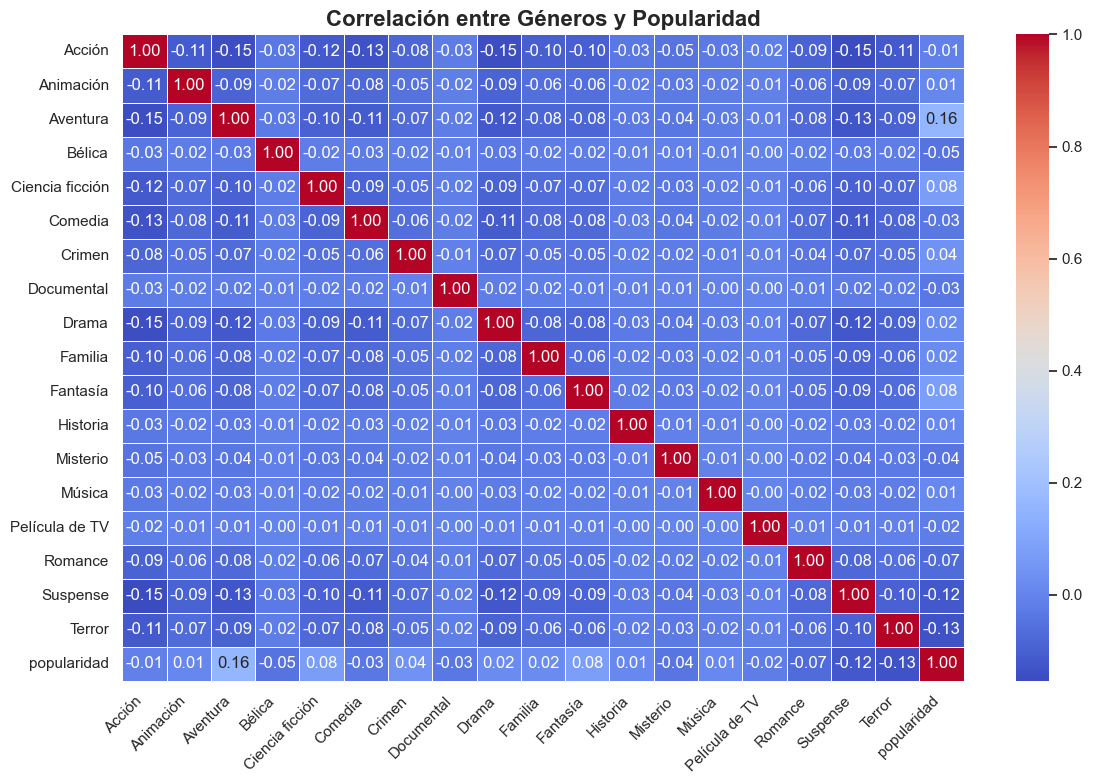

In [13]:
# Unir df_genres_dummies con la columna "popularidad"
df_corr = df_genres_dummies.copy()
df_corr['popularidad'] = df['popularidad']

# Calcular la correlación
correlation_matrix = df_corr.corr()

# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Crear un heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Mejorar la apariencia
plt.title('Correlación entre Géneros y Popularidad', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# Mostrar el gráfico
plt.show()


## Nube de Palabras de las Sinopsis de Películas más Puntuadas

Este gráfico de nube de palabras muestra las palabras más frecuentes en las sinopsis de las películas con las puntuaciones más altas, proporcionando una visualización intuitiva de los términos más comunes. Los pasos realizados son:

1. Se filtraron las películas con las mejores puntuaciones, seleccionando aquellas cuyo puntaje esté en el 10% superior de todas las películas.
2. Las sinopsis de estas películas fueron unidas en un solo texto y preprocesadas: se eliminaron los signos de puntuación y se convirtió todo el texto a minúsculas.
3. Se creó una lista personalizada de palabras vacías (`stopwords`) para excluir términos comunes como "de", "que", "y", entre otros, y se combinó con la lista de palabras vacías predeterminada de la biblioteca `WordCloud`.
4. Se generó la nube de palabras utilizando la librería `WordCloud`, personalizando aspectos como el tamaño, el color y la inclusión de palabras vacías.
5. Finalmente, la nube de palabras fue mostrada en un gráfico sin ejes, con un título que describe su contenido.

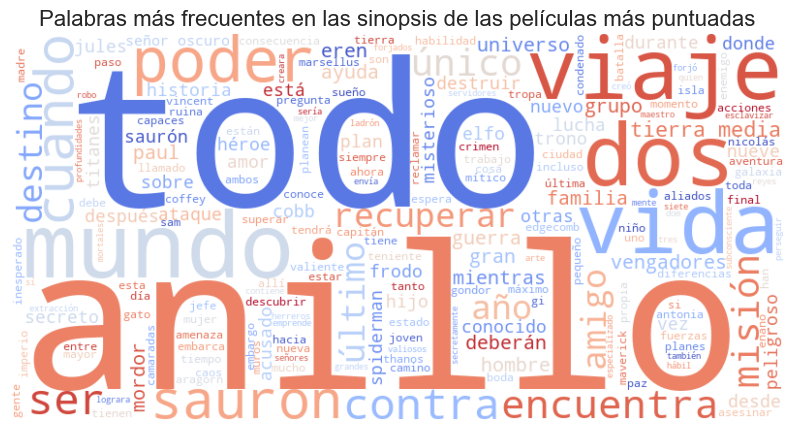

In [14]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import re

# Lista personalizada de palabras vacías (agregar las que quieras excluir)
custom_stopwords = {'de', 'que', 'y', 'en', 'a', 'la', 'las', 'el','al', 'le', 
'los', 'un', 'una', 'con', 'para', 'por', 'del', 'su','se','como','ha','sus','e','ha','sin','lo','muy','tras','es', 'pero', 'más'}

# Filtrar las películas con la puntuación más alta
top_movies = df[df['puntuacion'] >= df['puntuacion'].quantile(0.9)]  # Películas en el 10% superior de puntuación

# Unir todas las sinopsis en un solo texto
synopsis_text = ' '.join(top_movies['sinopsis'].dropna())

# Preprocesamiento: eliminar puntuación y convertir a minúsculas
synopsis_text = re.sub(r'[^\w\s]', '', synopsis_text.lower())

# Agregar las palabras vacías personalizadas a la lista de stopwords de WordCloud
stopwords = STOPWORDS.union(custom_stopwords)

# Crear la nube de palabras
wordcloud = WordCloud(
    width=800, height=400, 
    background_color='white', 
    colormap='coolwarm', 
    stopwords=stopwords
).generate(synopsis_text)

# Mostrar la nube de palabras
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frecuentes en las sinopsis de las películas más puntuadas', fontsize=16)
plt.show()


Filtramos las películas con una puntuación superior a 7, utilizando una máscara booleana basada en la columna 'puntuacion'. Las películas que cumplen con esta condición se almacenan en un nuevo DataFrame.


In [15]:
# Crear una máscara para filtrar películas con puntuación mayor a 7
mask_vote = df['puntuacion'] > 7

# Aplicar la máscara al DataFrame
df_filtrado = df[mask_vote]


In [16]:
df_filtrado.head()

,id,titulo,sinopsis,tokens_sinopsis,fecha_estreno,puntuacion,numero_votos,generos,idioma_original,idiomas_disponibles,reseñas,anio_estreno,popularidad
0,120,El señor de los anillos: La comunidad del anillo,"En la Tierra Media, el Señor Oscuro Saurón cre...","[En, la, Tierra, Media, ,, el, Señor, Oscuro, ...",2001-12-18,8.418,25770,"[Aventura, Fantasía, Acción]",en,[English],[],2001.0,7.628864
1,27205,Origen,"Dom Cobb es un ladrón hábil, el mejor de todos...","[Dom, Cobb, es, un, ladrón, hábil, ,, el, mejo...",2010-07-15,8.369,37220,"[Acción, Ciencia ficción, Aventura]",en,"[English, Français, 日本語, Kiswahili]",[Estamos ante una excelente y ambiciosa trama ...,2010.0,7.757741
4,667538,Transformers: El despertar de las bestias,Cuando surge una nueva amenaza capaz de destru...,"[Cuando, surge, una, nueva, amenaza, capaz, de...",2023-06-06,7.246,4842,"[Ciencia ficción, Aventura, Acción]",en,"[, Español, English]",[Transformers El Despertar de las Bestias (**T...,2023.0,6.687853
6,1356039,Contraataque,"En una misión de rescate de rehenes, el capitá...","[En, una, misión, de, rescate, de, rehenes, ,,...",2025-02-27,8.496,524,"[Acción, Aventura, Suspense]",es,[Español],[],2025.0,6.596741
9,950396,El abismo secreto,Dos agentes de élite son secretamente asignado...,"[Dos, agentes, de, élite, son, secretamente, a...",2025-02-13,7.747,2123,"[Romance, Ciencia ficción, Suspense]",en,"[English, Lietuvių]",[],2025.0,6.666092


In [17]:
# Crear una copia explícita del DataFrame para evitar el SettingWithCopyWarning
df_filtrado = df_filtrado.copy()

# Rellenar los valores nulos de la columna 'reseñas' con una cadena vacía
df_filtrado['reseñas'] = df_filtrado['reseñas'].fillna('')

In [18]:
# Asegurarse de que todos los valores en la columna 'reseñas' sean de tipo cadena (str)
# Esto convierte cualquier tipo de dato a string para que el procesamiento posterior sea consistente
df_filtrado['reseñas'] = df_filtrado['reseñas'].astype(str)


In [19]:
# Guardamos el DataFrame filtrado en formato parquet
df_filtrado.to_parquet('C:/Users/jugas/OneDrive/Escritorio/Movie recommender/MVP_sistema_recomendacion/proyecto/data/movies_filtrado.parquet')
